# Pfynwald HyPlant Coregistration Workflow

This notebook performs **geometric co-registration** of hyperspectral images using the **AROSICS** package (Scheffler et al. 2017).  
It aligns each image (from `shift_image_dir`) to a defined **reference image** (`ref_image_path`) through global coregistration.

Before and after co-registration, both the reference and target images are **cropped, masked and resampled (Lanczos)** to a defined **study area** (`study_area_path`) to:

- Ensure consistent spatial alignment,  
- Limit processing to the region of interest,  
- Maintain grid conformity after geometric correction.  

All resulting files are saved in `coreg_image_dir`.


#### Installation Notes — AROSICS on Windows

Installing **AROSICS** on Windows can be tricky due to dependencies like **GDAL**.  
Here’s the setup process that worked reliably for me:

```bash
# Create a new conda environment (Python 3.11)
conda create -c conda-forge --name arosics python=3.11
conda activate arosics

# Install GDAL first (this is often the main issue on Windows)
pip install gdal-installer
gdal-installer  # command-line setup for GDAL binaries

# Install required dependencies individually
pip install cartopy geopandas joblib matplotlib numpy pandas pyproj scikit-image shapely

# Finally, install AROSICS itself
pip install arosics
```

**Note:**  
The recommended installation via conda:

```bash
conda install -c conda-forge 'arosics>=1.3.0'
```

did **not** work for me due to the failing installation of GDAL.  


For further information, troubleshooting, and documentation, see: [AROSICS Official Documentation](https://danschef.git-pages.gfz-potsdam.de/arosics/doc/index.html)

In [74]:
# --- Basic imports ---
import os
import glob
import logging
from typing import Optional
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.mask import mask
from rasterio.plot import show
from osgeo import gdal
import matplotlib.pyplot as plt
import shutil
import tempfile
from pathlib import Path


# AROSICS is used for coregistration.
from arosics import COREG

In [75]:
# --- Logging ---
logging.basicConfig(level=logging.INFO, format='[%(levelname)s] %(message)s')
logger = logging.getLogger(__name__)

In [76]:
# %%
# --- Configuration ---

# PATHS
BASE_SHIFT_DIR = r"E:/Pfynwald/Data/HyPlant/original/"
COREG_DIR_BASE = r"E:/Pfynwald/Data/HyPlant/coregistration/"
STUDY_AREA_PATH = r"E:/Pfynwald/Data/General/studyarea.gpkg"

# TARGET FOLDER 
# (set to the specific folder you want to process)
FOLDER = "SIF_iFLD" # choose from: "TOC_REFL", "SIF_SFM", "SIF_SFMNN", "SIF_iFLD", "VI", "TASI"

# DATA-SPECIFIC PARAMETERS
EXT_MAP = {
"TOC_REFL": "bsq",
"SIF_SFM": "bil",
"SIF_SFMNN":"dat",
"SIF_iFLD": "bsq",
"VI": "bsq",
"TASI": "dat"
}

NODATA_MAP = {
"TOC_REFL": -999,
"SIF_SFM": -999,
"SIF_SFMNN":-999,
"SIF_iFLD": -999,
"VI": -999,
"TASI": 0
}

SB4MATCH_MAP = {
    "TOC_REFL": 1,
    "SIF_SFM": 2,
    "SIF_SFMNN": 11,
    "SIF_iFLD": 3,
    "VI": 1,
    "TASI": 1,
}

WS_MAP = {
    "TOC_REFL": (80, 80),
    "SIF_SFM": (220, 220),
    "SIF_SFMNN": (80, 80),
    "SIF_iFLD": (164, 164),
    "VI": (128, 128),
    "TASI": (80, 80),
}

# OTHER PARAMETERS
MAXSHIFT_MAP = {
    "TOC_REFL": 5,
    "SIF_SFM": 15,
    "SIF_SFMNN": 5,
    "SIF_iFLD": 15,
    "VI": 5,
    "TASI": 5,
}

# Reference image (set to the specific file you used before)
REF_IMAGE_PATH = os.path.join(BASE_SHIFT_DIR, "VI","20240823-PHY-1248-1340-L1-E-DUAL_radiance_img_atm_pol_indices_up-rect.bsq")
#REF_IMAGE_PATH = os.path.join(BASE_SHIFT_DIR, "TOC_REFL","20240823-PHY-1248-1340-L1-E-DUAL_radiance_img_atm_pol-rect.bsq") # choose for SIF_SFM
#REF_IMAGE_PATH = os.path.join(BASE_SHIFT_DIR, "TASI","TASI_2024_06_13_094307_atm_g_LST.dat")

NODATA_ORIG = NODATA_MAP[FOLDER]
NODATA_REF = NODATA_MAP["VI"]

# Output directory for this run
OUT_DIR = os.path.join(COREG_DIR_BASE, FOLDER)
os.makedirs(OUT_DIR, exist_ok=True)


In [77]:
# %%
# --- AROSICS kwargs ---

# Important to fine-tune, 
# especially adjusting ws and s_b4match necessary to senure proper co-registration.

COREG_KWARGS = {
'ws': WS_MAP[FOLDER], # matching window size [pixels] as (X, Y)
'nodata': (NODATA_REF, NODATA_ORIG), # no-data values for reference image and image to be shifted
'align_grids': False,
'fmt_out': 'ENVI', # raster file format for output file
'resamp_alg_deshift': 'lanczos', # the resampling algorithm to be used for shift correction
'max_shift': MAXSHIFT_MAP[FOLDER], # maximum shift distance in reference image pixel units
's_b4match': SB4MATCH_MAP[FOLDER] # band of shift image to be used for matching (otherwise starts with 1; default: 1)
}

In [78]:
# %%
# --- Helper functions ---

def _copy_band_metadata(src: rasterio.io.DatasetReader, dst: rasterio.io.DatasetWriter):
    """Copy band descriptions + per-band tags from src -> dst."""
    # band descriptions
    descs = list(src.descriptions) if src.descriptions is not None else None
    if descs:
        for i, d in enumerate(descs, start=1):
            if d:  # ignore empty
                dst.set_band_description(i, d)

    # per-band tags (optional but often useful)
    for i in range(1, src.count + 1):
        tags = src.tags(i)
        if tags:
            dst.update_tags(i, **tags)

    # dataset-level tags
    ds_tags = src.tags()
    if ds_tags:
        dst.update_tags(**ds_tags)


def crop_to_study_area(
    in_raster: str,
    study_area_path: str,
    out_raster: str,
    reference_raster: Optional[str] = None,
    nodata_value: Optional[float] = None,
    resampling: Resampling = Resampling.lanczos,
    force_dtype: Optional[str] = None,
):
    """Crop and (optionally) reproject/resample `in_raster` to the study area or match a reference grid.
    Preserves band descriptions & tags where possible.
    """
    with rasterio.open(in_raster) as src:
        src_crs = src.crs
        src_count = src.count
        src_dtype = src.dtypes[0]
        src_nodata = src.nodata

        use_nodata = nodata_value if nodata_value is not None else src_nodata

        study_gdf = gpd.read_file(study_area_path)
        if study_gdf.crs is None:
            raise ValueError(f"Study area has no CRS: {study_area_path}")
        if study_gdf.crs != src_crs:
            study_gdf = study_gdf.to_crs(src_crs)

        study_union = study_gdf.unary_union
        geoms = [study_union]

        masked_image, masked_transform = mask(src, geoms, crop=True, nodata=use_nodata)

        # Keep metadata to later copy to output
        src_descriptions = list(src.descriptions) if src.descriptions else None
        src_band_tags = [src.tags(i) for i in range(1, src_count + 1)]
        src_ds_tags = src.tags()

        masked_meta = src.meta.copy()
        masked_meta.update({
            'driver': 'GTiff',
            'height': masked_image.shape[1],
            'width': masked_image.shape[2],
            'transform': masked_transform,
            'nodata': use_nodata,
        })

    def _apply_bandmeta(dst):
        if src_descriptions:
            for i, d in enumerate(src_descriptions, start=1):
                if d:
                    dst.set_band_description(i, d)
        for i, tags in enumerate(src_band_tags, start=1):
            if tags:
                dst.update_tags(i, **tags)
        if src_ds_tags:
            dst.update_tags(**src_ds_tags)

    if reference_raster is None:
        out_dtype = force_dtype if force_dtype is not None else src_dtype
        masked_meta.update({'dtype': out_dtype, 'count': src_count})
        if force_dtype is not None and np.dtype(force_dtype) != np.dtype(masked_image.dtype):
            masked_image = masked_image.astype(force_dtype)

        with rasterio.open(out_raster, 'w', **masked_meta) as dst:
            dst.write(masked_image)
            _apply_bandmeta(dst)

        logger.info(f'Wrote cropped raster to: {out_raster}')
        return

    with rasterio.open(reference_raster) as ref:
        ref_transform = ref.transform
        ref_crs = ref.crs
        ref_height = ref.height
        ref_width = ref.width
        ref_profile = ref.profile.copy()
        ref_nodata = ref.nodata

    dest_nodata = nodata_value if nodata_value is not None else (ref_nodata if ref_nodata is not None else 0)
    dest_dtype = force_dtype if force_dtype is not None else src_dtype

    out_data = np.full((src_count, ref_height, ref_width), dest_nodata, dtype=np.dtype(dest_dtype))

    for b in range(src_count):
        reproject(
            source=masked_image[b],
            destination=out_data[b],
            src_transform=masked_transform,
            src_crs=src_crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=resampling,
            src_nodata=use_nodata,
            dst_nodata=dest_nodata,
        )

    ref_profile.update({'driver': 'GTiff', 'dtype': dest_dtype, 'count': src_count, 'nodata': dest_nodata})

    with rasterio.open(out_raster, 'w', **ref_profile) as dst:
        dst.write(out_data)
        _apply_bandmeta(dst)

    logger.info(f'Wrote reprojected raster matching reference grid to: {out_raster}')

# Small helper to display one band quickly
def quick_show(raster_path, band=1, title=None, cmap='viridis'):
    """
    Quick visualization helper.
    Automatically masks NoData values to improve contrast and display.
    """
    with rasterio.open(raster_path) as src:
        arr = src.read(band).astype(float)
        nodata = src.nodata

        # Mask nodata values
        if nodata is not None:
            arr = np.ma.masked_where(arr == nodata, arr)

        # Clip extreme values for better contrast
        vmin, vmax = np.percentile(arr.compressed(), (2, 98)) if arr.count() > 0 else (None, None)

        fig, ax = plt.subplots(figsize=(8, 6))
        show(arr, transform=src.transform, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title or os.path.basename(raster_path))
        plt.show()



In [79]:
# %%
# --- File discovery ---
INPUT_DIR = os.path.join(BASE_SHIFT_DIR, FOLDER)
pattern = f"*.{EXT_MAP[FOLDER]}" if not EXT_MAP[FOLDER].startswith('.') else f"*{EXT_MAP[FOLDER]}"
shift_images = glob.glob(os.path.join(INPUT_DIR, pattern))

# Optionally, subset images
shift_images = [p for p in shift_images if "2023" in os.path.basename(p)]

# Remove reference image from list for coregistration, but keep track if it exists
ref_in_shift = REF_IMAGE_PATH in shift_images
shift_images = [p for p in shift_images if os.path.abspath(p) != os.path.abspath(REF_IMAGE_PATH)]

print(f"Found {len(shift_images)} shift images (excluding reference) in: {INPUT_DIR}")
for p in shift_images:
    print(' -', os.path.basename(p))


Found 2 shift images (excluding reference) in: E:/Pfynwald/Data/HyPlant/original/SIF_iFLD
 - FS_iFLD_20230617-PHY-1117-1360-L1-E-FLUO_radiance_deconv_i1FIXDEM_V5_noborder-rect.bsq
 - FS_iFLD_20230617-PHY-1124-1360-L2-W-FLUO_radiance_deconv_i1FIXDEM_V5_noborder-rect.bsq


In [80]:
'''
# %% --- Update band names in an existing coreg folder (in-place) ---

COREG_FOLDER = r"E:/Pfynwald/Data/HyPlant/coregistration/TASI"
ORIG_FOLDER  = r"E:/Pfynwald/Data/HyPlant/original/TASI"

# extension of originals for SIF_SFM (from your EXT_MAP): "bil"
ORIG_EXT = "dat"

def copy_bandnames_to_existing_geotiff(src_path: str, dst_tif_path: str, make_backup: bool = True):
    with rasterio.open(src_path) as src:
        src_desc = list(src.descriptions) if src.descriptions else []
        src_count = src.count
        src_band_tags = [src.tags(i) for i in range(1, src_count + 1)]
        src_ds_tags = src.tags()

    if not any(d for d in src_desc):
        logger.warning("No band descriptions found in source: %s", os.path.basename(src_path))

    if make_backup:
        bak = dst_tif_path + ".bak"
        if not os.path.exists(bak):
            shutil.copy2(dst_tif_path, bak)
            logger.info("Backup created: %s", bak)

    with rasterio.open(dst_tif_path, "r+") as dst:
        n = min(dst.count, src_count)

        for i in range(1, n + 1):
            d = src_desc[i-1] if i-1 < len(src_desc) else None
            if d:
                dst.set_band_description(i, d)

        for i in range(1, n + 1):
            tags = src_band_tags[i-1] if i-1 < len(src_band_tags) else {}
            if tags:
                dst.update_tags(i, **tags)

        if src_ds_tags:
            dst.update_tags(**src_ds_tags)

    logger.info("Updated band names in: %s", dst_tif_path)


# --- Find all already-coregistered rasters in the folder ---
dst_files = sorted(glob.glob(os.path.join(COREG_FOLDER, "*_coreg_resampled.tif")))

updated = 0
missing_src = 0
errors = 0

for dst_tif in dst_files:
    stem = os.path.basename(dst_tif).replace("_coreg_resampled.tif", "")
    src_path = os.path.join(ORIG_FOLDER, f"{stem}.{ORIG_EXT}")

    if not os.path.exists(src_path):
        logger.warning("Missing source for %s -> expected %s", os.path.basename(dst_tif), os.path.basename(src_path))
        missing_src += 1
        continue

    try:
        copy_bandnames_to_existing_geotiff(src_path, dst_tif, make_backup=True)
        updated += 1
    except Exception as e:
        logger.error("Failed updating %s: %s", os.path.basename(dst_tif), e)
        errors += 1

print(f"\nDone. Updated: {updated}, Missing sources: {missing_src}, Errors: {errors}")
'''


'\n# %% --- Update band names in an existing coreg folder (in-place) ---\n\nCOREG_FOLDER = r"E:/Pfynwald/Data/HyPlant/coregistration/TASI"\nORIG_FOLDER  = r"E:/Pfynwald/Data/HyPlant/original/TASI"\n\n# extension of originals for SIF_SFM (from your EXT_MAP): "bil"\nORIG_EXT = "dat"\n\ndef copy_bandnames_to_existing_geotiff(src_path: str, dst_tif_path: str, make_backup: bool = True):\n    with rasterio.open(src_path) as src:\n        src_desc = list(src.descriptions) if src.descriptions else []\n        src_count = src.count\n        src_band_tags = [src.tags(i) for i in range(1, src_count + 1)]\n        src_ds_tags = src.tags()\n\n    if not any(d for d in src_desc):\n        logger.warning("No band descriptions found in source: %s", os.path.basename(src_path))\n\n    if make_backup:\n        bak = dst_tif_path + ".bak"\n        if not os.path.exists(bak):\n            shutil.copy2(dst_tif_path, bak)\n            logger.info("Backup created: %s", bak)\n\n    with rasterio.open(dst_tif_p

Reference: E:/Pfynwald/Data/HyPlant/original/VI\20240823-PHY-1248-1340-L1-E-DUAL_radiance_img_atm_pol_indices_up-rect.bsq
Cropped output: E:/Pfynwald/Data/HyPlant/coregistration/SIF_iFLD\nocoreg\ref_image_cropped.tif


C:\Users\avinn\AppData\Local\Temp\ipykernel_29764\2224799938.py:51: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  study_union = study_gdf.unary_union
[INFO] Wrote cropped raster to: E:/Pfynwald/Data/HyPlant/coregistration/SIF_iFLD\nocoreg\ref_image_cropped.tif


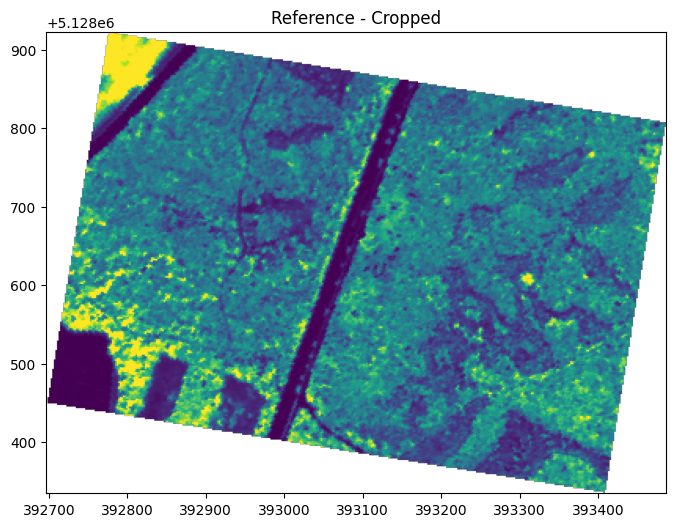

C:\Users\avinn\AppData\Local\Temp\ipykernel_29764\2224799938.py:51: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  study_union = study_gdf.unary_union
[INFO] Wrote reprojected raster matching reference grid to: C:\Users\avinn\AppData\Local\Temp\coreg_FS_iFLD_20230617-PHY-1117-1360-L1-E-FLUO_radiance_deconv_i1FIXDEM_V5_noborder-rect_qljglbb3\tmp_cropped_FS_iFLD_20230617-PHY-1117-1360-L1-E-FLUO_radiance_deconv_i1FIXDEM_V5_noborder-rect.bsq.tif
[INFO] Coregistering C:\Users\avinn\AppData\Local\Temp\coreg_FS_iFLD_20230617-PHY-1117-1360-L1-E-FLUO_radiance_deconv_i1FIXDEM_V5_noborder-rect_qljglbb3\tmp_cropped_FS_iFLD_20230617-PHY-1117-1360-L1-E-FLUO_radiance_deconv_i1FIXDEM_V5_noborder-rect.bsq.tif -> C:\Users\avinn\AppData\Local\Temp\coreg_FS_iFLD_20230617-PHY-1117-1360-L1-E-FLUO_radiance_deconv_i1FIXDEM_V5_noborder-rect_qljglbb3\FS_iFLD_20230617-PHY-1117-1360-L1-E-FLUO_radiance_deconv_i1FIXDEM_V5_noborder-rect_coreg.tif



[INFO] Processing: FS_iFLD_20230617-PHY-1117-1360-L1-E-FLUO_radiance_deconv_i1FIXDEM_V5_noborder-rect.bsq
Calculating footprint polygon and actual data corner coordinates for reference image...


Polygonize progress     |==================================================| 100.0% Complete  => 0:00:00
Polygonize progress     |==================================================| 100.0% Complete  => 0:00:00
C:\Users\avinn\AppData\Local\Temp\ipykernel_29764\2224799938.py:51: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  study_union = study_gdf.unary_union


Bounding box of calculated footprint for reference image:
	(392698.569, 5128334.964, 393486.569, 5128920.964)
Calculating footprint polygon and actual data corner coordinates for image to be shifted...
Bounding box of calculated footprint for image to be shifted:
	(392700.569, 5128334.964, 393486.569, 5128902.964)
Matching window position (X,Y): 393095.91527266934/5128625.896174607
Detected integer shifts (X/Y):                            -1/-15
Detected subpixel shifts (X/Y):                           0.4035695195198059/0.47622305154800415
Calculated total shifts in fft pixel units (X/Y):         -0.5964304804801941/-14.523776948451996
Calculated total shifts in reference pixel units (X/Y):   -0.5964304804801941/-14.523776948451996
Calculated total shifts in target pixel units (X/Y):      -0.5964304804801941/-14.523776948451996
Calculated map shifts (X,Y):                              -1.1928609609603882/29.04755389690399
Calculated absolute shift vector length in map units:     29.07

[INFO] Wrote reprojected raster matching reference grid to: E:/Pfynwald/Data/HyPlant/coregistration/SIF_iFLD\FS_iFLD_20230617-PHY-1117-1360-L1-E-FLUO_radiance_deconv_i1FIXDEM_V5_noborder-rect_coreg_resampled.tif


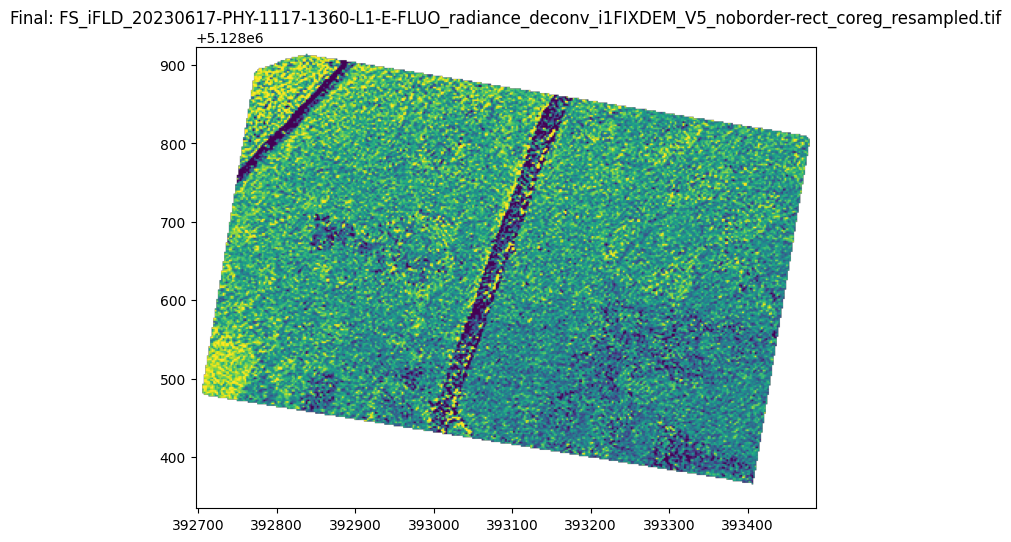

C:\Users\avinn\AppData\Local\Temp\ipykernel_29764\2224799938.py:51: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  study_union = study_gdf.unary_union
[INFO] Wrote reprojected raster matching reference grid to: C:\Users\avinn\AppData\Local\Temp\coreg_FS_iFLD_20230617-PHY-1124-1360-L2-W-FLUO_radiance_deconv_i1FIXDEM_V5_noborder-rect_y_izt50d\tmp_cropped_FS_iFLD_20230617-PHY-1124-1360-L2-W-FLUO_radiance_deconv_i1FIXDEM_V5_noborder-rect.bsq.tif
[INFO] Coregistering C:\Users\avinn\AppData\Local\Temp\coreg_FS_iFLD_20230617-PHY-1124-1360-L2-W-FLUO_radiance_deconv_i1FIXDEM_V5_noborder-rect_y_izt50d\tmp_cropped_FS_iFLD_20230617-PHY-1124-1360-L2-W-FLUO_radiance_deconv_i1FIXDEM_V5_noborder-rect.bsq.tif -> C:\Users\avinn\AppData\Local\Temp\coreg_FS_iFLD_20230617-PHY-1124-1360-L2-W-FLUO_radiance_deconv_i1FIXDEM_V5_noborder-rect_y_izt50d\FS_iFLD_20230617-PHY-1124-1360-L2-W-FLUO_radiance_deconv_i1FIXDEM_V5_noborder-rect_coreg.tif
Polygonize pro


[INFO] Processing: FS_iFLD_20230617-PHY-1124-1360-L2-W-FLUO_radiance_deconv_i1FIXDEM_V5_noborder-rect.bsq
Calculating footprint polygon and actual data corner coordinates for reference image...


Polygonize progress     |==================================================| 100.0% Complete  => 0:00:00
Polygonize progress     |==================================================| 100.0% Complete  => 0:00:00
[ERROR] Coregistration failed for FS_iFLD_20230617-PHY-1124-1360-L2-W-FLUO_radiance_deconv_i1FIXDEM_V5_noborder-rect.bsq: The length of the given lists must be equal to the number of bands. Received a list with 3 items for 'STATISTICS_APPROXIMATE'.
[INFO] Saved fallback (no coreg): E:/Pfynwald/Data/HyPlant/coregistration/SIF_iFLD\nocoreg\FS_iFLD_20230617-PHY-1124-1360-L2-W-FLUO_radiance_deconv_i1FIXDEM_V5_noborder-rect_clipped_nocoreg.tif


Bounding box of calculated footprint for reference image:
	(392698.569, 5128334.964, 393486.569, 5128920.964)
Calculating footprint polygon and actual data corner coordinates for image to be shifted...
Bounding box of calculated footprint for image to be shifted:
	(392698.569, 5128334.964, 393486.569, 5128920.964)
Matching window position (X,Y): 393092.1502917078/5128628.092120771
Detected integer shifts (X/Y):                            0/-15
Detected subpixel shifts (X/Y):                           0.48118484020233154/0.26522761583328247
Calculated total shifts in fft pixel units (X/Y):         0.48118484020233154/-14.734772384166718
Calculated total shifts in reference pixel units (X/Y):   0.48118484020233154/-14.734772384166718
Calculated total shifts in target pixel units (X/Y):      0.48118484020233154/-14.734772384166718
Calculated map shifts (X,Y):                              0.9623696804046631/29.469544768333435
Calculated absolute shift vector length in map units:     29.485

In [81]:
# --- Subfolder for "clipped only / no coreg" products ---
NOCOREG_DIR = os.path.join(OUT_DIR, "nocoreg")
os.makedirs(NOCOREG_DIR, exist_ok=True)

# --- Crop reference image (store in nocoreg folder as well) ---
REF_CROPPED = os.path.join(NOCOREG_DIR, 'ref_image_cropped.tif')
print('Reference:', REF_IMAGE_PATH)
print('Cropped output:', REF_CROPPED)

crop_to_study_area(
    REF_IMAGE_PATH, STUDY_AREA_PATH, REF_CROPPED,
    reference_raster=None,
    nodata_value=NODATA_REF
)
quick_show(REF_CROPPED, title='Reference - Cropped')

# --- Coregistration loop ---
for im_shift in shift_images:
    filename = os.path.basename(im_shift)
    stem = os.path.splitext(filename)[0]
    print('\n[INFO] Processing:', filename)

    clipped_fallback = os.path.join(NOCOREG_DIR, f"{stem}_clipped_nocoreg.tif")
    final_out = os.path.join(OUT_DIR, f"{stem}_coreg_resampled.tif")

    with tempfile.TemporaryDirectory(prefix=f"coreg_{stem}_") as tmpdir:
        tmpdir = Path(tmpdir)

        tmp_cropped = str(tmpdir / f"tmp_cropped_{filename}.tif")
        coreg_out = str(tmpdir / f"{stem}_coreg.tif")

        try:
            crop_to_study_area(
                im_shift, STUDY_AREA_PATH, tmp_cropped,
                reference_raster=REF_CROPPED,
                nodata_value=NODATA_ORIG
            )

            # Save clipped-only output in subfolder
            shutil.copy2(tmp_cropped, clipped_fallback)

            logger.info('Coregistering %s -> %s', tmp_cropped, coreg_out)
            cr = COREG(REF_CROPPED, tmp_cropped, path_out=coreg_out, **COREG_KWARGS)
            cr.correct_shifts()

            crop_to_study_area(
                coreg_out, STUDY_AREA_PATH, final_out,
                reference_raster=REF_CROPPED,
                nodata_value=NODATA_ORIG
            )

            try:
                quick_show(final_out, title=f'Final: {os.path.basename(final_out)}')
            except Exception:
                logger.warning('Could not quick-show %s', final_out)

        except Exception as e:
            logger.error("Coregistration failed for %s: %s", filename, e)
            logger.info("Saved fallback (no coreg): %s", clipped_fallback)
            continue

print('\n[INFO] Done. Processed images written to:', OUT_DIR)

# --- Process reference image if it was originally in shift images ---
if ref_in_shift:
    ref_filename = os.path.basename(REF_IMAGE_PATH)
    ref_cropped_snap = os.path.join(OUT_DIR, f"{os.path.splitext(ref_filename)[0]}_coreg_resampled.tif")


    crop_to_study_area(
    REF_IMAGE_PATH,
    STUDY_AREA_PATH,
    out_raster=ref_cropped_snap,
    reference_raster=REF_CROPPED,
    nodata_value=NODATA_REF
    )
    quick_show(ref_cropped_snap, title='Reference Image - Cropped & Resampled')


print('\n[INFO] Done. Processed images written to:', OUT_DIR)